In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import selfies as sf
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import math
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, DataStructs, rdmolops, Descriptors, rdMolDescriptors, QED
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
#import plotly.express as px
from IPython.display import display
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
import re
import difflib

import sys
import sascorer

torch.cuda.empty_cache()

In [28]:
from datasets import load_dataset

ds = load_dataset("edmanft/zinc250k")["train"]

print(ds)
print(ds.column_names)

Dataset({
    features: ['index', 'smiles', 'selfies', 'logP', 'qed', 'SAS'],
    num_rows: 249455
})
['index', 'smiles', 'selfies', 'logP', 'qed', 'SAS']


In [3]:
df = ds.to_pandas()

print(df.head())

   index                                             smiles  \
0      0          CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n   
1      1     C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n   
2      2  N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...   
3      3  CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...   
4      4  N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...   

                                             selfies     logP       qed  \
0  [C][C][Branch1][C][C][Branch1][C][C][C][=C][C]...  5.05060  0.702012   
1  [C][C@@H1][C][C][Branch2][Ring1][Ring2][N][C][...  3.11370  0.928975   
2  [N][#C][C][=C][C][=C][Branch2][Ring2][Ring2][C...  4.96778  0.599682   
3  [C][C][O][C][=Branch1][C][=O][C@@H1][C][C][C][...  4.00022  0.690944   
4  [N][#C][C][=C][Branch2][Ring1][Ring1][S][C][C]...  3.60956  0.789027   

        SAS  
0  2.084095  
1  3.432004  
2  2.470633  
3  2.822753  
4  4.035182  


In [4]:
# prepare dataset
df['tokens'] = df['selfies'].apply(lambda x: list(sf.split_selfies(x)))
vocab = sorted(set([tok for seq in df['tokens'] for tok in seq]))
#vocab = sorted(list(sf.get_semantic_robust_alphabet()))
PAD, SOS, EOS, MASK = "<PAD>", "<SOS>", "<EOS>", "MASK"
vocab = [PAD, SOS, EOS, MASK] + vocab
vocab_size = len(vocab)

tok2id = {tok: idx for idx, tok in enumerate(vocab)}
id2tok = {idx: tok for tok, idx in tok2id.items()}

def molecule_tok2id(tokens, tok2id):
    return np.array([1] + [tok2id[t] for t in tokens] + [2])

df['token_ids'] = df['tokens'].apply(lambda toks: molecule_tok2id(toks, tok2id))
#df['lenghts'] = df['token_ids'].apply(len)

sequences = df['token_ids'].tolist()
max_len = max(len(seq) for seq in sequences)
padded_data = np.zeros((len(sequences), max_len), dtype=sequences[0].dtype)

for i, seq in enumerate(sequences):
    padded_data[i, :len(seq)] = seq

data = padded_data#[:100_000]
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42, shuffle=True)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42, shuffle=True)

In [6]:
# utilities
@torch.no_grad()
def accuracy(model, loader, mode='eval', pad_id=0, device='cuda'):
    model.eval()

    total_correct = 0
    total_tok = 0
    total_seq = 0
    perfect = 0

    for x in loader:
        x = x.to(device)

        if mode == 'train':
            logits, _, _ = model(x, mode=mode)
            targets = x[:, 1:]

            pred = logits.argmax(dim=-1)

            mask = (targets != pad_id)

            correct = (pred == targets) & mask

            total_correct += correct.sum().item()
            total_tok += mask.sum().item()

            seq_correct = (correct.sum(dim=1) == mask.sum(dim=1))
            perfect += seq_correct.sum().item()
            total_seq += x.size(0)

        else:
            tokens, _, _ = model(x, mode='eval')

            for i, pred in enumerate(tokens):
                true = x[i]
                mask = (true != pad_id)
                true_len = mask.sum().item()

                if true_len == 0:
                    continue
                if len(pred) < true_len:
                    pad = torch.full((true_len - len(pred),), pad_id, device=pred.device, dtype=pred.dtype)
                    pred = torch.cat([pred, pad], dim=0)
                else:
                    pred = pred[:true_len]

                true = true[:true_len]
                correct = (pred == true)
                total_correct += correct.sum().item()
                total_tok += true_len
                perfect += int(correct.all())
                total_seq += 1

    return (
        total_correct / max(total_tok, 1),
        perfect / max(total_seq, 1)
    )

In [7]:
# model
class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        pe = torch.zeros(max_len, hidden_size)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, hidden_size, 2).float() * (-math.log(10000.0) / hidden_size))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        if x.dim() == 3:
            B, T, _ = x.shape
        elif x.dim() == 2:
            B, T = x.shape
        if T <= self.pe.size(0):
            pe = self.pe[:T]  
        else:
            device = x.device
            H = self.hidden_size
            position = torch.arange(T, dtype=torch.float, device=device).unsqueeze(1)  
            div_term = torch.exp(torch.arange(0, H, 2, device=device).float() * (-math.log(10000.0)/H))
            pe = torch.zeros(T, H, device=device)
            pe[:, 0::2] = torch.sin(position * div_term)
            pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)  

class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_size, num_heads):
        super().__init__()
        self.d = hidden_size // num_heads
        self.num_heads = num_heads
        self.W_q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_v = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.norm1 = nn.LayerNorm(hidden_size)
        self.ff = nn.Sequential(
            nn.Linear(hidden_size, 2 * hidden_size),
            nn.GELU(),
            nn.Dropout(p=0.1),
            nn.Linear(2 * hidden_size, hidden_size),
            nn.Dropout(p=0.1)
        )
        self.norm2 = nn.LayerNorm(hidden_size)

    def forward(self, q, k, v, pad_mask=None, causal=False):   # [B, T, H]
        B, T_q, H = q.shape
        _, T_v, _ = v.shape
        Q = self.W_q(q)     # [B, T, num_heads * H]
        K = self.W_k(k)
        Vx = self.W_v(v)
        Q = Q.view(B, self.num_heads, T_q, self.d) # [B, A, T, H]
        K = K.view(B, self.num_heads, T_v, self.d)
        V = Vx.view(B, self.num_heads, T_v, self.d)

        attn_logits = torch.einsum('baih,bajh->baij', Q, K)    # [B, A, T, H] @ [B, A, H, T] = [B, A, T, T]

        if pad_mask is not None:
            key_mask = pad_mask[:, None, None, :]  # [B,1,1,T_k]
            attn_logits = attn_logits.masked_fill(~key_mask, float('-inf'))

        attn = F.softmax(attn_logits / math.sqrt(self.d), dim=-1)

        if pad_mask is not None:
            query_mask = pad_mask[:, None, :, None]  # [B,1,T_q,1]
            attn = attn * query_mask.float()

        h = torch.einsum('baij,bajh->baih',attn, V)  # [B, A, T, H]
        h = h.view(B, T_q, H)  # [B, T, A*H]

        # soft XSA
        # Vn = F.normalize(Vx, dim=-1)
        # h = h - 0.8 * (h * Vn).sum(dim=-1, keepdim=True) * Vn
        
        h = q + self.W_o(h)     # [B, T, H]
        h = h + self.ff(self.norm2(h))
        h = self.norm1(h)
        return h

class MultiSlotPooling(nn.Module):
    def __init__(self, hidden_size, num_slots):
        super().__init__()
        self.queries = nn.Parameter(torch.empty(num_slots, hidden_size))
        nn.init.uniform_(self.queries, a=-1.0, b=1.0)        
        self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_v = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, h, mask):
        # h: [B, T, D]
        # mask: [B, T]
        k = self.W_k(h)
        v = self.W_v(h)
        attn = torch.einsum("kd,btd->bkt", self.queries, k)
        attn = attn.masked_fill(~mask[:, None, :], -1e9)
        attn = F.softmax(attn, dim=-1) / math.sqrt(h.size(-1))
        slots = torch.einsum("bkt,btd->bkd", attn, v)
        return slots
    

class VaeTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_size, latent_size, max_len, attn_heads=8, num_slots=8, encoder_layers=1, decoder_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_slots = num_slots
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.pos_encoder = PositionalEmbedding(max_len, hidden_size)
        self.conv_pos = nn.Conv1d(hidden_size, hidden_size, kernel_size=3, padding=1, groups=hidden_size)
        
        # Encoder
        self.pos_block = MultiHeadAttention(hidden_size, attn_heads)
        self.encoder_blocks = nn.ModuleList([MultiHeadAttention(hidden_size, attn_heads) for _ in range(encoder_layers)])
        self.pool = MultiSlotPooling(hidden_size, num_slots=num_slots)
        #self.slot_pos_encoder = nn.Parameter(torch.randn(1, num_slots, hidden_size))
        self.slots_mix = MultiHeadAttention(hidden_size, num_heads=num_slots)

        self.slot_gamma = nn.Parameter(torch.ones(1, num_slots, hidden_size))
        self.slot_beta = nn.Parameter(torch.zeros(1, num_slots, hidden_size))
        #nn.init.orthogonal_(self.slot_beta[0])

        # VAE heads
        self.slot_mu = nn.Linear(hidden_size, latent_size)
        self.slot_logvar = nn.Linear(hidden_size, latent_size)  
        
        self.slot_compress_mu = nn.Linear(hidden_size, latent_size // num_slots)
        self.slot_compress_logvar = nn.Linear(hidden_size, latent_size // num_slots)

        self.fc_mu = nn.Linear(num_slots * hidden_size, latent_size)
        self.fc_logvar = nn.Linear(num_slots * hidden_size, latent_size)
        
        # pooling in latent space with uncertanty
        self.latent_query = nn.Parameter(torch.randn(1, 1, latent_size))
        self.latent_key = nn.Linear(latent_size, latent_size)

        # Decoder
        self.max_len = max_len
        self.z_to_slot = nn.Linear(hidden_size // num_slots, hidden_size)
        #self.slot_pos_decoder = nn.Parameter(torch.randn(1, num_slots, hidden_size))
        self.decoder_embed = nn.Embedding(vocab_size, hidden_size)

        self.decoder_pos = PositionalEmbedding(max_len, hidden_size)

        self.z_to_memory = nn.Linear(latent_size, hidden_size)
        self.slots_to_memory = nn.Linear(latent_size // num_slots, hidden_size)

        self.decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_size,
            nhead=attn_heads,
            dim_feedforward=2 * hidden_size,
            batch_first=True
        )

        self.decoder_transformer = nn.TransformerDecoder(
            self.decoder_layer,
            num_layers=decoder_layers
        )
        # Output head
        self.fc_output = nn.Linear(hidden_size, vocab_size)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def causal_mask(self, T, device):
        return torch.triu(
            torch.ones(T, T, device=device),
            diagonal=1
        ).bool()
    
    def encode(self, x, mode=None):  
        B, _ = x.shape
        h = self.embedding(x)    # [B, T, H]
        fourier_pos_encoding = self.pos_encoder(x)
        conv_pos_encoding = self.conv_pos(h.transpose(1, 2)).transpose(1, 2)
        h = h + fourier_pos_encoding + conv_pos_encoding
        mask = (x != 0)
        
        for block in self.encoder_blocks:
            h = block(h, h, h, pad_mask=mask)
            
        h = h.masked_fill(~mask[:, :, None], 0.0)

        slots = self.pool(h, mask)
        slots = F.layer_norm(slots, slots.shape[-1:])
        #slots = slots * self.slot_gamma + self.slot_beta

        B, K, Z = slots.shape

        slots_mu = self.slot_mu(slots)
        slots_logvar = self.slot_logvar(slots)

        # Latent pool from slots with uncertanty
        q = F.normalize(self.latent_query.expand(B, 1, Z), dim=-1)
        k = F.normalize(self.latent_key(slots_mu), dim=-1)

        logits = torch.einsum("bqz,bkz->bqk", q, k)

        confidence = -torch.logsumexp(slots_logvar, dim=-1).unsqueeze(1) #-slots_logvar.mean(dim=-1).unsqueeze(1)
        confidence_scale = 0.5

        logits = logits + confidence_scale * confidence
        attn = torch.softmax(logits / 0.5, dim=-1)

        mu = torch.einsum("bqk,bkz->bqz", attn, slots_mu).squeeze(1)

        var = torch.exp(slots_logvar)
        var_agg = torch.einsum("bqk,bkz->bqz", attn, var).squeeze(1)
        logvar = torch.log(var_agg + 1e-8)
        
        if mode == "test":
            return mu, logvar, slots
        else:
            return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z, x_in=None, max_len=80, start_id=1, eos_id=2):
        B = z.size(0)
        device = z.device

        memory = self.z_to_memory(z).unsqueeze(1)

        if x_in is not None:
            x_emb = self.decoder_embed(x_in)
            x_emb = x_emb + self.decoder_pos(x_emb)

            T = x_emb.size(1)
            tgt_mask = self.causal_mask(T, device)

            h = self.decoder_transformer(
                tgt=x_emb,
                memory=memory,
                tgt_mask=tgt_mask
            )

            logits = self.fc_output(h)   # ✔️ [B, T, V]
            return logits

        else:
            tokens = torch.full((B, 1), start_id, dtype=torch.long, device=device)
            finished = torch.zeros(B, dtype=torch.bool, device=device)
            max_len = self.max_len * 2

            for _ in range(max_len):
                x_emb = self.decoder_embed(tokens)
                x_emb = x_emb + self.decoder_pos(x_emb)

                T = tokens.size(1)
                tgt_mask = self.causal_mask(T, device)

                h = self.decoder_transformer(
                    tgt=x_emb,
                    memory=memory,
                    tgt_mask=tgt_mask
                )

                logits_step = self.fc_output(h[:, -1])  # [B, V]

                next_token = torch.argmax(logits_step, dim=-1, keepdim=True)

                next_token = torch.where(
                    finished.unsqueeze(1),
                    torch.full_like(next_token, eos_id),
                    next_token
                )

                tokens = torch.cat([tokens, next_token], dim=1)

                finished |= (next_token.squeeze(1) == eos_id)

                if finished.all():
                    break

            return tokens
            
    def forward(self, x, mode='eval'):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)

        if mode == 'train':
            x_in = x[:, :-1]

            logits = self.decode(z, x_in=x_in)

            return logits, mu, logvar
    

        if mode == "eval":
            tokens = self.decode(z, x_in=None)

            return tokens, mu, logvar 
        
        if mode == "test":
            mu, logvar, slots = self.encode(x, mode="test")
            z = self.reparameterize(mu, logvar)

            tokens = self.decode(z, x_in=None)

            return tokens, mu, logvar, slots


def vae_loss(logits, targets, mu, logvar, beta=0.01, pad_id=0):
    B, T, V = logits.shape

    logits = logits.reshape(-1, V)
    targets = targets.reshape(-1)

    rec_loss = F.cross_entropy(
        logits,
        targets,
        ignore_index=pad_id
    )

    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return rec_loss + beta * kl, rec_loss, kl

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

hidden_size = 256
attention_heads = 8
encoder_layers = 3
decoder_layers = 2
latent_size = 256

model = VaeTransformer(
    vocab_size,
    hidden_size,
    latent_size,
    max_len,
    attention_heads,
    encoder_layers=encoder_layers,
    decoder_layers=decoder_layers
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

beta = 0.01
epochs = 50
batch_size = 256
mask_prob = 0.05
corruption = False
max_beta = 0.03
cycle_lenght = 15

history = []
best_acc = 0

train_loader = DataLoader(train_data, batch_size, shuffle=True, num_workers=8)
val_loader = DataLoader(val_data, batch_size, shuffle=False, num_workers=8)

for epoch in range(1, epochs + 1):

    model.train()

    total_loss = 0
    total_rec = 0
    total_kl = 0

    pbar = tqdm(train_loader, dynamic_ncols=True, leave=False)

    # KL annealing
    # if epoch < 20:
    #     #beta = 0
    #     corruption = False
    # else:
    #     #beta = min(0.5, epoch / 60)
    #     corruption = False
    beta = (epoch % cycle_lenght / cycle_lenght) * max_beta

    for x in pbar:
        x = x.to(device)

        # input corruption
        if corruption:
            prob = torch.rand_like(x.float())

            mask = prob < mask_prob
            rand = (prob >= mask_prob) & (prob < mask_prob + 0.1)
            keep = (prob >= mask_prob + 0.1) & (prob < mask_prob + 0.2)
            
            x_corrupt = x.clone()
            x_corrupt[mask] = 3 # mask_token_id
            x_corrupt[rand] = torch.randint(0, vocab_size, size=x[rand].shape, device=x.device)

            pad_mask = (x == 0)
            x_corrupt[pad_mask] = 0

            logits, mu, logvar = model(x_corrupt, mode='train')
        else:
            logits, mu, logvar = model(x, mode='train')

        targets = x[:, 1:]

        loss, rec, kl = vae_loss(
            logits, targets, mu, logvar, beta=beta
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_rec += rec.item()
        total_kl += kl.item()

        pbar.set_postfix({
            "rec": f"{rec.item():.3f}",
            "kl": f"{kl.item():.3f}",
            "tot": f"{loss.item():.3f}",
        })

    model.eval()
    
    val_loss_total = 0
    with torch.no_grad():
        for x in val_loader:
            x = x.to(device)

            logits, mu, logvar = model(x, mode='train')
            targets = x[:, 1:]

            val_loss, val_rec, val_kl = vae_loss(
                logits, targets, mu, logvar, beta=beta
            )

            val_loss_total += val_loss.item()


    token_acc, seq_acc = accuracy(model, val_loader, mode='train')

    total_loss /= len(train_loader)
    total_rec /= len(train_loader)
    total_kl /= len(train_loader)
    val_loss_total /= len(val_loader)

    history.append((total_loss, total_rec, total_kl, val_loss_total))

    print(
        f"Epoch: {epoch:03d} | "
        f"loss={total_loss:.4f} | rec={total_rec:.4f} | kl={total_kl:.4f} | "
        f"val={val_loss_total:.4f} | "
        f"token_acc={token_acc*100:.2f}% | seq_acc={seq_acc*100:.2f}%"
    )

    if seq_acc > best_acc:
        best_acc = seq_acc

        ckpt = {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "history": history,
            "vocab_size": vocab_size
        }
    
        torch.save(
            ckpt,
            "trained-models/Final-ZINC250K.pt"
        )

        print("saved")

In [ ]:
# load properties and confounds dataframe
Y = pd.read_csv('data/molecule_properties.csv')
X = pd.read_csv('data/confound_features.csv')    

In [ ]:
def get_molecule_properties(mol):
    return {
        "molWt": Descriptors.MolWt(mol),
        "HeavyAtomCount": mol.GetNumHeavyAtoms(),
        "cLogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRingCount": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "NumSpiroAtoms": rdMolDescriptors.CalcNumSpiroAtoms(mol),
        "NumBridgeheadAtoms": rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
        "BertzCT": Descriptors.BertzCT(mol),
        "QED": QED.qed(mol),
        "SA-score": sascorer.calculateScore(mol)
    }

def clean_selfie_ids(ids):
    result = []
    for tok in ids:
        if tok == 1:
            continue
        if tok == 2 or tok == 0:
            return result
        result.append(tok)
    return result

def latents_to_mol(model, z):
    ids = model.decode(z)
    tokens = [[id2tok[id] for id in clean_selfie_ids(seq)] for seq in ids.cpu().numpy()]
    selfies = [''.join(toks) for toks in tokens]
    mols = []
    for selfie in selfies:
        try:
            smi = sf.decoder(selfie)
            mol = Chem.MolFromSmiles(smi)
            mols.append(mol)  
        except:
            mols.append(None)
            print(smi)
    return mols

In [ ]:
# prepare and save dataframe with confounds and molecular propeties
def shannon_entropy(tokens):
    if len(tokens) == 0:
        return 0.0
    counts = pd.Series(tokens).value_counts().to_numpy(dtype=float)
    p = counts / counts.sum()
    return float(-(p * np.log(p)).sum())

tqdm.pandas()
X = pd.DataFrame({
    "selfies_len_tokens": df["tokens"].apply(len).astype(float),
    "branch_token_count": df["tokens"].apply(lambda t: sum("Branch" in x for x in t)).astype(float),
    "ring_token_count": df["tokens"].apply(lambda t: sum("Ring" in x for x in t)).astype(float),
    "token_entropy": df["tokens"].apply(shannon_entropy),
})

def safe_props(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return get_molecule_properties(mol) if mol else None

tqdm.pandas()
Y = (df['smiles'].progress_map(safe_props))
Y = pd.DataFrame(Y.tolist())

# save features and properties dataframes
X.to_csv('data/confound_features_ZINC250K.csv', index=False)
Y.to_csv('data/molecule_properties_ZINC250K.csv', index=False)

In [ ]:
# save features and properties dataframes
X.to_csv('data/confound_features_ZINC250K.csv', index=False)
Y.to_csv('data/molecule_properties_ZINC250K.csv', index=False)

In [23]:
# extract latents for linear probe
def extract_latents(data, model):
    loader = DataLoader(data, batch_size=128, shuffle=False)
    zs = []
    model.eval()
    with torch.no_grad():
        for x in tqdm(loader):
            x = x.to(device)
            mu, _ = model.encode(x)
            zs.append(mu.cpu().numpy())
    z = np.concatenate(zs, axis=0)
    return z

z = extract_latents(data, model)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1949/1949 [00:08<00:00, 243.22it/s]


In [24]:
# first train Ridge Confound -> Y, then latent -> Y - Y(C) where Y is molecule property
for target_name in Y.columns:
    print(f"\n=== Predicting {target_name} ===")
    y = Y[target_name].values
    xc_train, xc_test, z_train, z_test, y_train, y_test = train_test_split(X, z, y, test_size=0.2, random_state=42)

    confound_model = Pipeline([
        ("scaler", StandardScaler()),
        ("linear", LinearRegression())
    ])  

    confound_model.fit(xc_train, y_train)

    y_train_conf = confound_model.predict(xc_train)
    y_test_conf = confound_model.predict(xc_test)
    print("confound R2:", r2_score(y_test, y_test_conf))

    res_train = y_train - y_train_conf
    res_test = y_test - y_test_conf

    linear_probe = Pipeline([
        ("scaler", StandardScaler()),
        ("linear", LinearRegression())
    ])
    linear_probe.fit(z_train, res_train)
    res_pred = linear_probe.predict(z_test)
    print("residual R2:", r2_score(res_test, res_pred)) 


=== Predicting molWt ===
confound R2: 0.8711660468372722
residual R2: 0.530924851942884

=== Predicting HeavyAtomCount ===
confound R2: 0.9392767515798983
residual R2: 0.6872187296347931

=== Predicting cLogP ===
confound R2: 0.1471678258091541
residual R2: 0.6576395445458136

=== Predicting TPSA ===
confound R2: 0.3297745636258147
residual R2: 0.5952350433176372

=== Predicting HBD ===
confound R2: 0.013433169843376724
residual R2: 0.388070069166113

=== Predicting HBA ===
confound R2: 0.34109435400921917
residual R2: 0.5800163679701178

=== Predicting NumRotatableBonds ===
confound R2: 0.15775120408607946
residual R2: 0.37448383461391943

=== Predicting RingCount ===
confound R2: 0.6388084867186412
residual R2: 0.8361865709778865

=== Predicting AromaticRingCount ===
confound R2: 0.3846299181916176
residual R2: 0.7608896981528601

=== Predicting FractionCSP3 ===
confound R2: 0.2636117016132573
residual R2: 0.854119605775552

=== Predicting NumSpiroAtoms ===
confound R2: 0.0149195925

In [26]:
Y.head()

,molWt,HeavyAtomCount,cLogP,TPSA,HBD,HBA,NumRotatableBonds,RingCount,AromaticRingCount,FractionCSP3,NumSpiroAtoms,NumBridgeheadAtoms,BertzCT,QED,SA-score
0,325.383,24,5.05060,42.24,1,2,3,3,3,0.250000,0,0,890.035395,0.731901,2.084095
1,285.395,21,3.11370,55.63,1,4,3,3,2,0.562500,0,0,596.219734,0.941112,3.432004
2,382.463,29,4.96778,53.33,0,3,5,4,3,0.200000,0,0,999.443934,0.626105,2.470633
3,409.530,30,4.00022,64.43,0,4,4,4,2,0.541667,0,0,916.522527,0.716225,2.822753
4,413.910,28,3.60956,112.10,1,6,4,3,1,0.400000,1,0,922.868756,0.809572,4.035182


  0%|                                                                                                                                                                  | 0/12 [00:00<?, ?it/s]

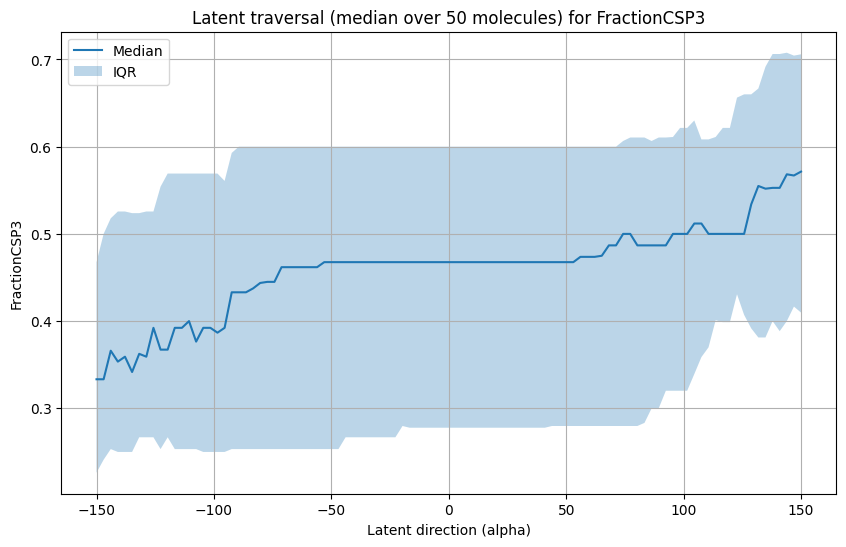

  8%|████████████▊                                                                                                                                             | 1/12 [00:11<02:10, 11.83s/it]

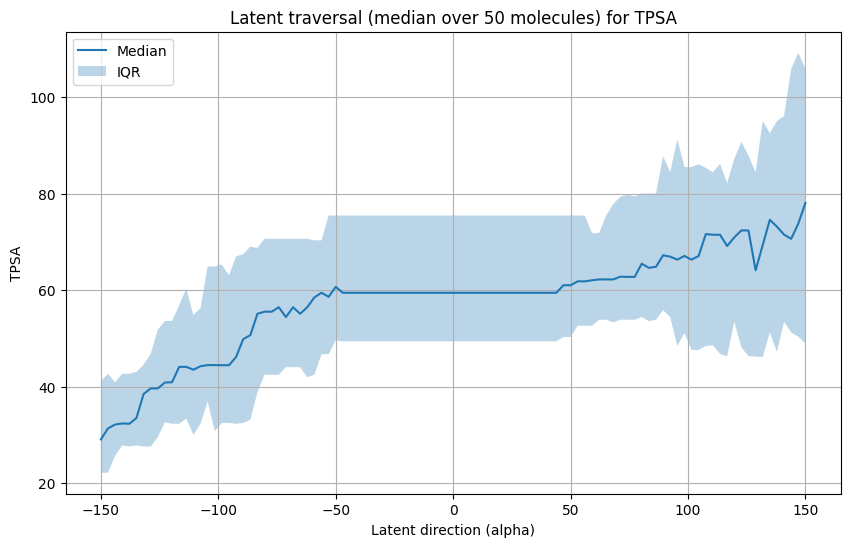

 17%|█████████████████████████▋                                                                                                                                | 2/12 [00:22<01:53, 11.31s/it]

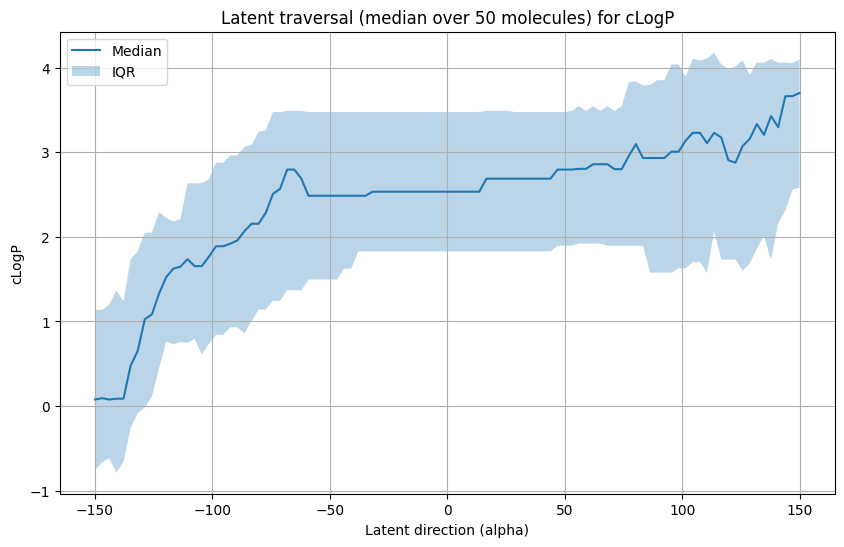

 25%|██████████████████████████████████████▌                                                                                                                   | 3/12 [00:35<01:48, 12.06s/it]

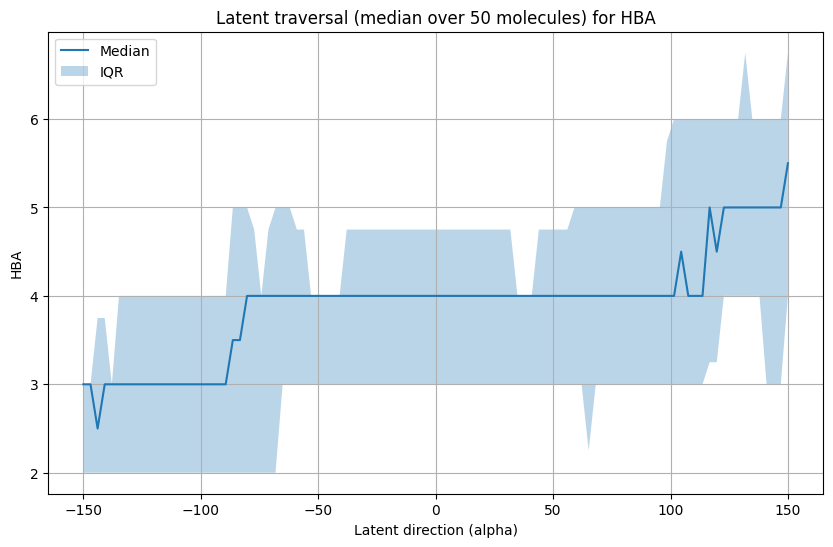

 33%|███████████████████████████████████████████████████▎                                                                                                      | 4/12 [00:47<01:35, 11.89s/it]

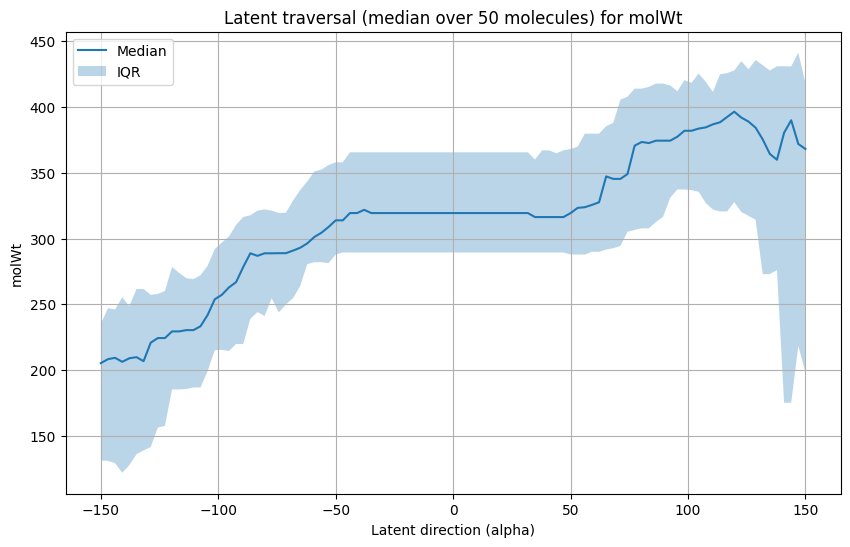

 42%|████████████████████████████████████████████████████████████████▏                                                                                         | 5/12 [00:58<01:21, 11.60s/it]

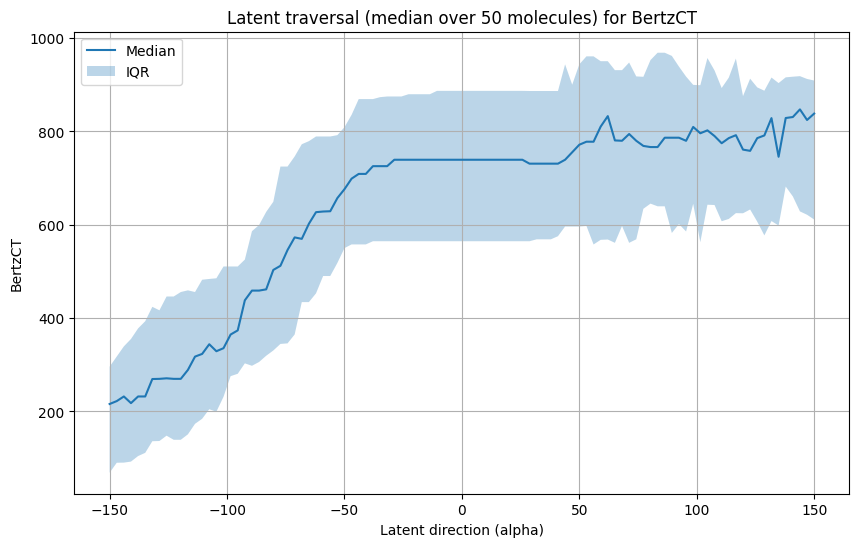

 50%|█████████████████████████████████████████████████████████████████████████████                                                                             | 6/12 [01:11<01:12, 12.13s/it]

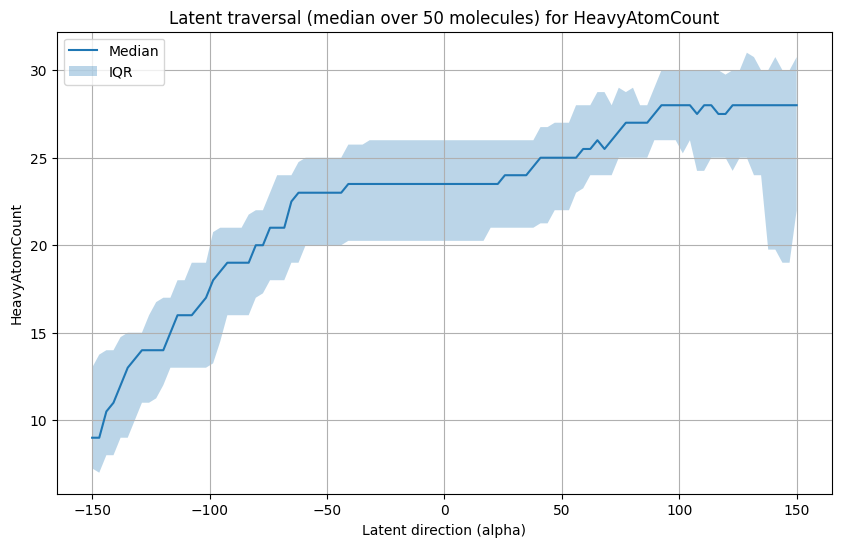

 58%|█████████████████████████████████████████████████████████████████████████████████████████▊                                                                | 7/12 [01:22<00:59, 11.80s/it]

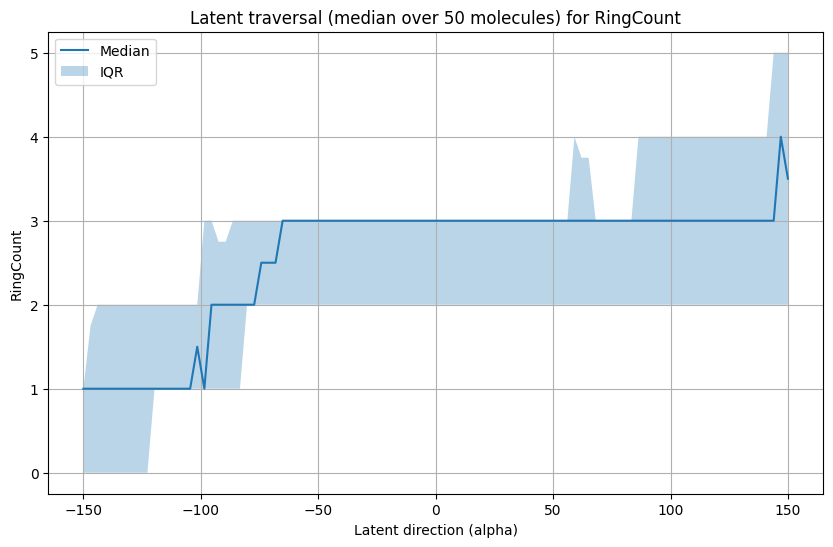

 67%|██████████████████████████████████████████████████████████████████████████████████████████████████████▋                                                   | 8/12 [01:34<00:47, 11.93s/it]

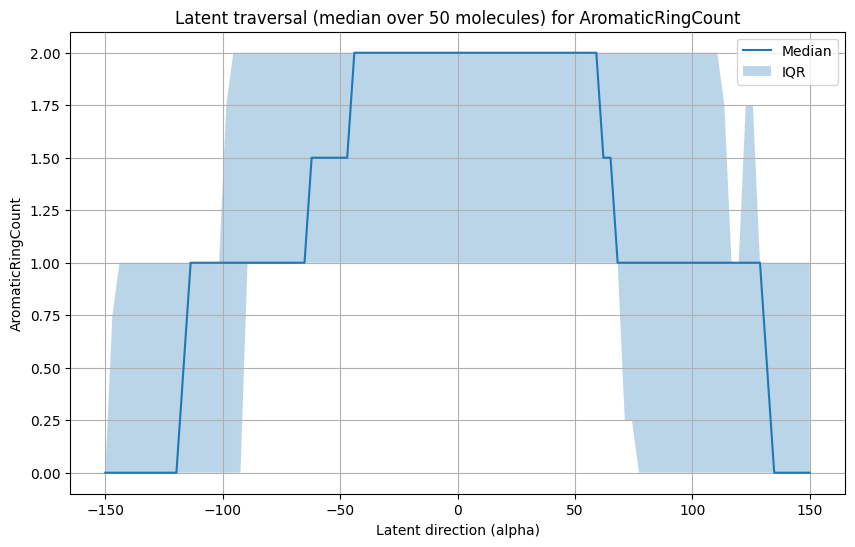

 75%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                      | 9/12 [01:46<00:35, 11.95s/it]

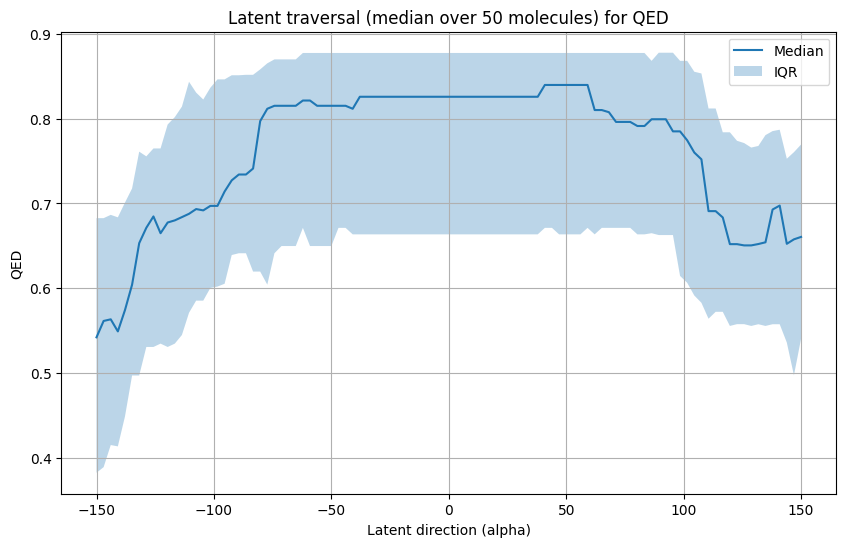

 83%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                         | 10/12 [02:01<00:25, 12.80s/it]

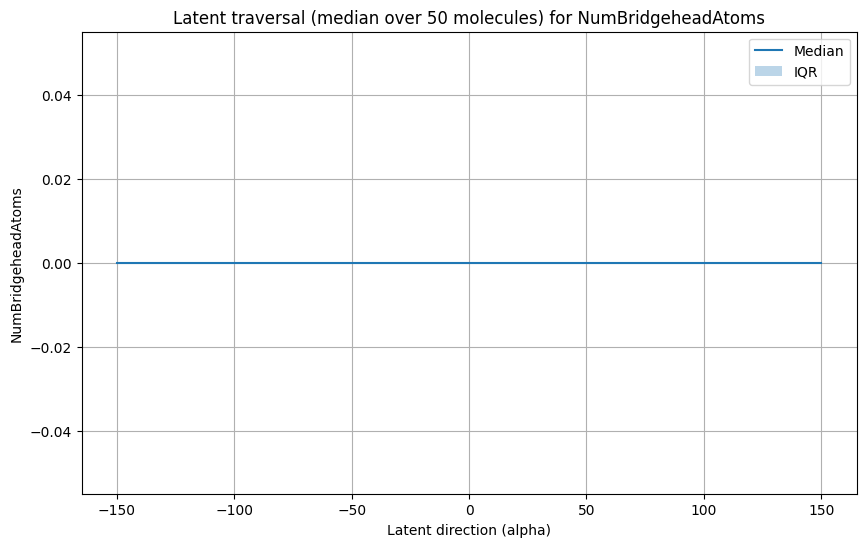

 92%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎            | 11/12 [02:12<00:12, 12.21s/it]

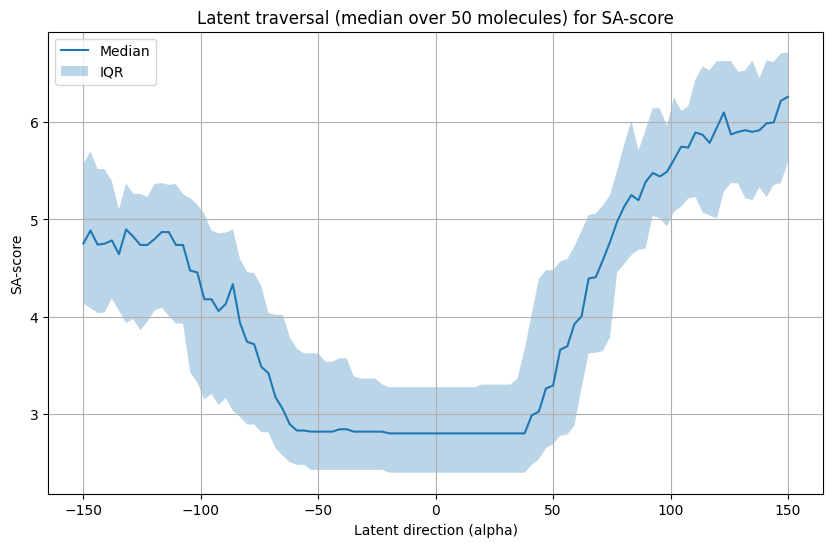

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [02:25<00:00, 12.10s/it]


In [27]:
# gobal latent traversal plot
target_names = ["FractionCSP3", "TPSA", "cLogP", "HBA", "molWt","BertzCT", "HeavyAtomCount", "RingCount", "AromaticRingCount", "QED", "NumBridgeheadAtoms","SA-score"] # Plot for these properties

steps = 100
scale = 150.0
k = 50

for target_name in tqdm(target_names):
    # latent interpolation in rigde direction for poperty
    y = Y[target_name].values
    z_train, z_test, y_train, y_test = train_test_split(z, y, test_size=0.2, random_state=42)

    linear_model = Pipeline([
        ("scaler", StandardScaler()),
        ("linear", LinearRegression())
    ])
    linear_model.fit(z_train, y_train)

    weights_raw = linear_model.named_steps["linear"].coef_
    std = linear_model.named_steps["scaler"].scale_
    weights = weights_raw / std
    weights /= np.linalg.norm(weights)

    #idx = np.random.randint(len(y))
    # sampling from mid molecule in terms of property value
    # idx = Y[target_name].sort_values().index[len(Y) // 2]
    # z0 = z[idx]
    #z0 = np.zeros(latent_size)#np.random.randn(latent_size)  # random point in latent space

    # sorted_idx = Y[target_name].sort_values().index
    # mid = len(sorted_idx) // 2

    # # take a window around median
    # half_k = k // 2
    # selected_idx = sorted_idx[mid - half_k : mid + half_k]

    idx = np.random.randint(0, len(Y), size=k)

    z0_batch = z[idx]   # shape: (k, latent_dim)
    
    def interpolate_batch(z0_batch, direction, steps=1000, scale=100.0):
        alphas = np.linspace(-scale, scale, steps)  # (steps,)
        
        # reshape for broadcasting
        z0_batch = z0_batch[:, None, :]      # (k, 1, d)
        direction = direction[None, None, :] # (1, 1, d)
        alphas = alphas[None, :, None]       # (1, steps, 1)
        
        zs = z0_batch + alphas * direction   # (k, steps, d)
        
        return zs, alphas.squeeze()

    zs, alphas = interpolate_batch(z0_batch, weights, steps, scale)

    k, steps, d = zs.shape
    zs_flat = zs.reshape(-1, d) 

    batch_size = 2048

    props = np.full((k, steps), np.nan)

    model.eval()

    for step_idx, alpha in enumerate(alphas):
        zs_step = z0_batch + alpha * weights   # (k, d)

        row_props = []

        with torch.no_grad():
            for i in range(0, k, batch_size):
                batch = zs_step[i:i+batch_size]
                zs_tensor = torch.tensor(batch, dtype=torch.float32).to(device)

                tokens = model.decode(zs_tensor)
                tokens_list = tokens.detach().cpu().tolist()

                for toks in tokens_list:
                    toks = clean_selfie_ids(toks)
                    selfies = ''.join([id2tok[int(id)] for id in toks])
                    smiles = sf.decoder(selfies)

                    mol = Chem.MolFromSmiles(smiles)
                    if mol:
                        val = compute_property(mol, target_name)
                    else:
                        val = np.nan

                    row_props.append(val)

        props[:, step_idx] = row_props

    median_props = np.nanmedian(props, axis=0)  # (steps,)

    alphas = np.array(alphas)
    q25 = np.nanpercentile(props, 25, axis=0)
    q75 = np.nanpercentile(props, 75, axis=0)
    
    plt.figure(figsize=(10, 6))

    plt.plot(alphas, median_props, label="Median")
    plt.fill_between(alphas, q25, q75, alpha=0.3, label="IQR")

    plt.xlabel("Latent direction (alpha)")
    plt.ylabel(target_name)
    plt.title(f"Latent traversal (median over {k} molecules) for {target_name}")
    plt.legend()
    plt.grid()

    plt.show()
    plt.close()